# Temporal prediction

In [1]:
# Suppress TensorFlow warnings and info messages
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress INFO and WARNING messages
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Only if you want to specify GPU

# Essential imports only
import sys
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# TensorFlow with GPU memory growth
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

#  Configure GPU memory growth for JupyterHub
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
   tf.config.experimental.set_memory_growth(gpus[0], True)
   print(">> GPU configured with memory growth for JupyterHub")
   print(f"   * Available GPU: {gpus[0]}")
  except RuntimeError as e:
   print(f"! GPU configuration warning: {e}")
else:
  print("! No GPU found")

# Auto-detect training directory based on project structure
def find_training_directory():
  """Find the training directory automatically based on project structure."""

  # Method 1: Check if we're already in the training directory
  if os.path.exists('config.py') and os.path.exists('utils.py'):
   return os.getcwd()

  # Method 2: Look for sbndcode structure from common paths
  possible_bases = [
   # Standard LArSoft development paths
   "/exp/sbnd/app/users/{}/larsoft_*/srcs/sbndcode",
   "/exp/sbnd/app/users/{}/*/srcs/sbndcode",
   # Alternative paths
   "/home/{}/sbndcode",
   "/home/{}/larsoft_*/srcs/sbndcode",
   # Current directory relatives
   "./sbndcode",
   "../sbndcode",
   "../../sbndcode",
  ]

  # Get current user
  import getpass
  username = getpass.getuser()

  # Expand paths with username and wildcards
  import glob
  expanded_paths = []
  for base in possible_bases:
   if '{}' in base:
    base = base.format(username)
   if '*' in base:
    expanded_paths.extend(glob.glob(base))
   else:
    expanded_paths.append(base)

  # Check each potential sbndcode directory
  for sbndcode_path in expanded_paths:
   training_path = os.path.join(sbndcode_path, "sbndcode", "PosRecoCVN", "training")
   if os.path.exists(training_path) and os.path.exists(os.path.join(training_path, "config.py")):
    return training_path

  # Method 3: Search upwards from current directory
  current = os.getcwd()
  for _ in range(5):  # Don't go too far up
   training_path = os.path.join(current, "sbndcode", "PosRecoCVN", "training")
   if os.path.exists(training_path) and os.path.exists(os.path.join(training_path, "config.py")):
    return training_path
   parent = os.path.dirname(current)
   if parent == current:  # reached root
    break
   current = parent

  return None

# Find and set training directory
print(">> Auto-detecting training directory...")
training_dir = find_training_directory()

if training_dir:
  print(f">> Found training directory: {training_dir}")
  if os.getcwd() != training_dir:
   print(f"   * Changing directory from {os.getcwd()} to {training_dir}")
   os.chdir(training_dir)
else:
  print("! Could not find training directory automatically")
  print("* Manual setup options:")
  print("  1. Navigate to your training directory:")
  print("     os.chdir('/path/to/your/sbndcode/sbndcode/PosRecoCVN/training')")
  print("  2. Or copy the required files:")
  print("     !cp /path/to/your/training/config.py .")
  print("     !cp /path/to/your/training/utils.py .")
  print("  3. Or add your training directory to Python path:")
  print("     sys.path.append('/path/to/your/training/directory')")

# Add current directory to Python path
if os.getcwd() not in sys.path:
  sys.path.append(os.getcwd())

# Debug info
print(f"\n* Current working directory: {os.getcwd()}")
print(f"* config.py exists: {os.path.exists('config.py')}")
print(f"* utils.py exists: {os.path.exists('utils.py')}")

# Try to import local modules
config_imported = False
utils_imported = False

try:
  from config import *
  config_imported = True
  print(">> config module imported successfully")
except ImportError as e:
  print(f"! config import error: {e}")

try:
  from utils import *
  utils_imported = True
  print(">> utils module imported successfully")
except ImportError as e:
  print(f"! utils import error: {e}")

if not (config_imported and utils_imported):
  print("\n* If auto-detection failed, try one of these solutions:")
  print("  1. Manual directory change:")
  print("     os.chdir('/exp/sbnd/app/users/YOUR_USERNAME/larsoft_*/srcs/sbndcode/sbndcode/PosRecoCVN/training')")
  print("  2. Add to Python path:")
  print("     sys.path.append('/path/to/your/training/directory')")
  print("  3. Copy files to current directory")
  print("\n   Then restart this cell.")

# Only run these if modules were imported successfully
if config_imported and utils_imported:
  print(" ============================================")
  print("   PosRecoCNN Training Pipeline - GPU Mode")
  print(" ============================================")
  print_config_summary()
  validate_paths()
else:
  print("! Skipping configuration check until modules are properly imported")

2025-11-28 11:11:29.451636: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-28 11:11:29.451788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-28 11:11:29.454445: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


>> GPU configured with memory growth for JupyterHub
   * Available GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
>> Auto-detecting training directory...
>> Found training directory: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training
   * Changing directory from /home/svidales to /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training

* Current working directory: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training
* config.py exists: True
* utils.py exists: True
>> config module imported successfully
>> utils module imported successfully
   PosRecoCNN Training Pipeline - GPU Mode
>> Configuration Summary
PMT Maps Directory: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/pmt_maps
Model Export Path: /exp/sbnd/data/users/svidales
Training Data: mc_MCP2025B_02_prodgenie_corsika_proton_rockbox_sbnd_CV_reco2_sbnd_30k_training.root
Te

In [2]:
# Load training data
print(">> Loading training data...")
import time
start_time = time.time()

file = uproot.open(DATA_CONFIG['training_file'])
optree = file['opanatree']['OpAnaTree']

if LOADING_CONFIG['load_all']:
  print(f"   * Loading all events: {optree.num_entries:,}")
  arrays = []
  for i, key in enumerate(DATA_CONFIG['keys_to_load']):
   print(f"     - Loading {key}... ({i+1}/{len(DATA_CONFIG['keys_to_load'])}) [{100*(i+1)/len(DATA_CONFIG['keys_to_load']):.1f}%]")
   array = optree[key].array()
   arrays.append(array)
else:
  n_total = optree.num_entries
  n_load = int(n_total * LOADING_CONFIG['fraction'])
  start = LOADING_CONFIG['start_event']
  end = start + n_load
  print(f"   * Loading events {start}-{end} ({n_load:,}/{n_total:,})")
  arrays = []
  for i, key in enumerate(DATA_CONFIG['keys_to_load']):
   print(f"     - Loading {key}... ({i+1}/{len(DATA_CONFIG['keys_to_load'])}) [{100*(i+1)/len(DATA_CONFIG['keys_to_load']):.1f}%]")
   array = optree[key].array(entry_start=start, entry_stop=end)
   arrays.append(array)

loading_time = time.time() - start_time

# Unpack arrays
f_ophit_PE, f_ophit_ch, f_ophit_t, dEpromx, dEpromy, dEpromz, nuvT, dEtpc, nuvZ = arrays

# Display loading statistics
print(">> Data loaded successfully")
print(f"   * Loading time: {loading_time:.2f} seconds")
print(f"   * Loaded {len(arrays)} arrays:")
for i, key in enumerate(DATA_CONFIG['keys_to_load']):
  array = arrays[i]
  array_size_mb = array.nbytes / (1024*1024)
  print(f"     - {key}: {len(array):,} events, {array_size_mb:.1f} MB")

total_size_mb = sum(array.nbytes for array in arrays) / (1024*1024)
print(f"   * Total data size: {total_size_mb:.1f} MB")
print(f"   * Loading speed: {total_size_mb/loading_time:.1f} MB/s")

>> Loading training data...
   * Loading all events: 497,317
     - Loading flash_ophit_pe... (1/9) [11.1%]
     - Loading flash_ophit_ch... (2/9) [22.2%]
     - Loading flash_ophit_time... (3/9) [33.3%]
     - Loading dEpromx... (4/9) [44.4%]
     - Loading dEpromy... (5/9) [55.6%]
     - Loading dEpromz... (6/9) [66.7%]
     - Loading nuvT... (7/9) [77.8%]
     - Loading dEtpc... (8/9) [88.9%]
     - Loading nuvZ... (9/9) [100.0%]
>> Data loaded successfully
   * Loading time: 1687.99 seconds
   * Loaded 9 arrays:
     - flash_ophit_pe: 497,317 events, 9349.0 MB
     - flash_ophit_ch: 497,317 events, 4681.6 MB
     - flash_ophit_time: 497,317 events, 9349.0 MB
     - dEpromx: 497,317 events, 11.4 MB
     - dEpromy: 497,317 events, 11.4 MB
     - dEpromz: 497,317 events, 11.4 MB
     - nuvT: 497,317 events, 10.6 MB
     - dEtpc: 497,317 events, 11.4 MB
     - nuvZ: 497,317 events, 10.6 MB
   * Total data size: 23446.5 MB
   * Loading speed: 13.9 MB/s


In [92]:
print(nuvZ)

[[186], [139], [214], [89.9, ...], ..., [-301, 443], [-356, 377], [94.5, -390]]


In [8]:
# Celda 1.5: Ejecuta esta celda después de modificar utils.py
import importlib
import utils
importlib.reload(utils)
from utils import *
print("✓ utils.py recargado con los cambios más recientes")

✓ utils.py recargado con los cambios más recientes


In [9]:
# Create channel dictionary
PDSMap = file['opanatree']['PDSMapTree']
ID = PDSMap['OpDetID'].array()
Type = PDSMap['OpDetType'].array()
channel_dict = {id_val: int(type_val) for id_val, type_val in zip(ID[0], Type[0])}
print(f">> Channel dictionary created: {len(channel_dict)} channels")

# Process events with centralized configuration
print("\n>> Processing events...")
results = process_events(
  nuvT, f_ophit_PE, f_ophit_ch, f_ophit_t,
  dEpromx, dEpromy, dEpromz, dEtpc, nuvZ,
  channel_dict, FILTER_CONFIG, verbose=True
)

# Unpack results
(nuvT_final, f_ophit_PE_final, f_ophit_ch_final, f_ophit_t_final,
 dEpromx_final, dEpromy_final, dEpromz_final, dEtpc_final, nuvZ_final, selected_tpc_final, stats) = results

>> Channel dictionary created: 312 channels

>> Processing events...
>> Starting optimized event processing...
Initial events: 497,317
Processing flashes...
Applying data validity cuts...
Applying energy cuts...
Applying position cuts...
>> Processing completed in 7.53 seconds

Initial events: 497,317


,Cut,Removed,Remaining,Cumulative_Eff
0,Single neutrino,287236,210081,0.422
1,Has flashes,3316,206765,0.416
2,Valid data (≠ -999 in dEprom),323,206442,0.415
3,Energy cut,10370,196072,0.394
4,Position cut,847,195225,0.393


Final efficiency: 0.393 (195,225/497,317)

* Final dataset ranges:
  dEpromx: [-200.0, 200.0]
  dEpromy: [-199.8, 199.8]
  dEpromz: [4.6, 500.0]
  dEtpc: [50.0, 7571.2]


## Preparación de datos para LSTM

**Ordenar ophits por tiempo dentro de cada flash**

In [10]:
# Obtener los índices ordenados de manera creciente dentro de cada flash
sorted_indices = ak.argsort(f_ophit_t_final, axis=-1, ascending=True)
# Ordenar los datos de los ophits dentro de cada flash
f_ophit_t_sorted = f_ophit_t_final[sorted_indices]  # Ordenar f_ophit_t
f_ophit_PE_sorted = f_ophit_PE_final[sorted_indices]  # Reordenar PE
f_ophit_ch_sorted = f_ophit_ch_final[sorted_indices]  # Reordenar canales

print(f">> Ophits ordenados por tiempo")
print(f"   * Total eventos: {len(f_ophit_t_sorted):,}")

>> Ophits ordenados por tiempo
   * Total eventos: 195,225


**Seleccionar los primeros n ophits de cada flash**

In [11]:
def select_top_ophits(f_ophit_t_sorted, f_ophit_PE_sorted, f_ophit_ch_sorted, max_ophits_per_flash=1000):
    """
    Selecciona los primeros n ophits de cada flash.
    
    Parameters:
    -----------
    f_ophit_t_sorted : awkward array
        Tiempos de ophits ordenados
    f_ophit_PE_sorted : awkward array
        Photoelectrons ordenados
    f_ophit_ch_sorted : awkward array
        Canales ordenados
    max_ophits_per_flash : int
        Número máximo de ophits a seleccionar por flash
    
    Returns:
    --------
    Tupla de (selected_t, selected_PE, selected_ch)
    """
    selected_t, selected_PE, selected_ch = [], [], []
    
    for event_idx in range(len(f_ophit_ch_sorted)):
        selected_event_t, selected_event_PE, selected_event_ch = [], [], []
        
        for flash_idx in range(len(f_ophit_ch_sorted[event_idx])):
            flash_ch = f_ophit_ch_sorted[event_idx][flash_idx]
            flash_t = f_ophit_t_sorted[event_idx][flash_idx]
            flash_PE = f_ophit_PE_sorted[event_idx][flash_idx]
            
            # Tomar solo los primeros max_ophits_per_flash ophits
            selected_event_t.append(flash_t[:max_ophits_per_flash])
            selected_event_PE.append(flash_PE[:max_ophits_per_flash])
            selected_event_ch.append(flash_ch[:max_ophits_per_flash])
        
        selected_t.append(selected_event_t)
        selected_PE.append(selected_event_PE)
        selected_ch.append(selected_event_ch)
    
    return ak.Array(selected_t), ak.Array(selected_PE), ak.Array(selected_ch)

In [61]:
selected_ophits_t, selected_ophits_PE, selected_ophits_ch = select_top_ophits(
    f_ophit_t_sorted, f_ophit_PE_sorted, f_ophit_ch_sorted, max_ophits_per_flash=30
)

print(f">> Ophits seleccionados (top 10 por flash)")
print(f"   * Shape: {len(selected_ophits_t):,} eventos")

>> Ophits seleccionados (top 10 por flash)
   * Shape: 195,225 eventos


### Corregir el ToF (Time of Flight) en las variables temporales

In [62]:
# Cálculo de ToF (Time of Flight)
# ToF_inside: tiempo que tarda la luz en viajar desde el punto de interacción hasta el detector
# nuvZ está en cm, velocidad de la luz en cm/ns
ToF_inside = ak.flatten(nuvZ_final) / 3E10 * 1E9  # Convertir a nanosegundos

# ToF_outside: tiempo de vuelo fuera del detector (110 cm a velocidad de luz en vacío)
ToF_outside = 110 / 3E8 * 1E9

# Separación entre bunches del haz
bunch_separation = 19  # ns

# Corregir nuvT
nuvT_c = nuvT_final - ToF_inside - ToF_outside

# Corregir tiempos de ophits (dos métodos)
selected_ophits_t_c_1 = selected_ophits_t * 1000 - ToF_inside - ToF_outside
selected_ophits_t_c_2 = selected_ophits_t * 1000 - ToF_inside - ak.flatten(nuvT_c) - ToF_outside

print(f">> ToF corrections calculated")
print(f"   * ToF_inside range: [{ak.min(ToF_inside):.2f}, {ak.max(ToF_inside):.2f}] ns")
print(f"   * ToF_outside: {ToF_outside:.2f} ns")
print(f"   * Bunch separation: {bunch_separation} ns")

>> ToF corrections calculated
   * ToF_inside range: [-59.08, 32.94] ns
   * ToF_outside: 366.67 ns
   * Bunch separation: 19 ns


### Crear el input para la LSTM

**Padding y regularización de arrays**

In [14]:
def pad_and_regularize(ak_array, num_ophits, num_flashes=4, pad_value=0.0):
    """
    Aplica padding a los arrays de ophits y flashes para regularizar las dimensiones.
    
    Parameters:
    -----------
    ak_array : awkward array
        Array a regularizar
    num_ophits : int
        Número de ophits por flash
    num_flashes : int
        Número de flashes por evento (default: 4)
    pad_value : float
        Valor para padding (default: 0.0)
    
    Returns:
    --------
    numpy array regularizado
    """
    # Step 1: Pad ophits per flash (asegurar que cada flash tenga num_ophits ophits)
    ak_padded_ophits = ak.pad_none(ak_array, num_ophits, axis=-1, clip=True)
    ak_filled_ophits = ak.fill_none(ak_padded_ophits, pad_value)

    # Step 2: Pad flashes por evento (asegurar que cada evento tenga num_flashes flashes)
    ak_padded_flashes = ak.pad_none(ak_filled_ophits, num_flashes, axis=-2, clip=True)
    ak_filled = ak.fill_none(ak_padded_flashes, pad_value)

    # Step 3: Convertir a un array regular de NumPy
    np_array = ak.to_numpy(ak_filled)
    
    # Si el resultado es un masked array, rellenamos los valores faltantes con -1000
    np_array = np.ma.filled(np_array, fill_value=-1000)

    return np_array

In [63]:
ophit_cut = 30

regular_ophit = pad_and_regularize(selected_ophits_t, num_ophits=ophit_cut)
regular_ch = pad_and_regularize(selected_ophits_ch, num_ophits=ophit_cut)
regular_PE = pad_and_regularize(selected_ophits_PE, num_ophits=ophit_cut)

# Reshape para aplanar flashes y ophits
regular_ophit_r = regular_ophit.reshape(regular_ophit.shape[0], 4*ophit_cut)
regular_ch_r = regular_ch.reshape(regular_ch.shape[0], 4*ophit_cut)
regular_pe_r = regular_PE.reshape(regular_PE.shape[0], 4*ophit_cut)

print(f">> Arrays regularizados y aplanados")
print(f"   * regular_ophit_r shape: {regular_ophit_r.shape}")
print(f"   * regular_ch_r shape: {regular_ch_r.shape}")
print(f"   * regular_pe_r shape: {regular_pe_r.shape}")

>> Arrays regularizados y aplanados
   * regular_ophit_r shape: (195225, 120)
   * regular_ch_r shape: (195225, 120)
   * regular_pe_r shape: (195225, 120)


**Crear channel_dict extendido con coordenadas espaciales**

In [68]:
# Crear diccionario extendido con coordenadas (type, x, y, z)
channel_dict_extended = {
    id_val: (int(type_val), round(float(x_val), 2), round(float(y_val), 2), round(float(z_val), 2)) 
    for id_val, type_val, x_val, y_val, z_val in zip(
        ID[0], Type[0], 
        PDSMap['OpDetX'].array()[0], 
        PDSMap['OpDetY'].array()[0], 
        PDSMap['OpDetZ'].array()[0]
    )
}

print(f">> Channel dictionary extendido creado: {len(channel_dict_extended)} channels")
print(f"   * Estructura: channel_id -> (type, x, y, z)")
print(f"   * Ejemplo (channel 0): {channel_dict_extended.get(0, 'N/A')}")

>> Channel dictionary extendido creado: 312 channels
   * Estructura: channel_id -> (type, x, y, z)
   * Ejemplo (channel 0): (3, -213.75, -135.0, 20.25)


In [69]:
# Mapear canales a sus propiedades (type, x, y, z)
n_fotodetector = np.vectorize(lambda x: channel_dict_extended.get(x, (-1000, -1000, -1000, -1000))[0])(regular_ch_r)
x_fotodetector = np.vectorize(lambda x: channel_dict_extended.get(x, (-1000, -1000, -1000, -1000))[1])(regular_ch_r)
y_fotodetector = np.vectorize(lambda x: channel_dict_extended.get(x, (-1000, -1000, -1000, -1000))[2])(regular_ch_r)
z_fotodetector = np.vectorize(lambda x: channel_dict_extended.get(x, (-1000, -1000, -1000, -1000))[3])(regular_ch_r)

print(f">> Coordenadas de fotodetectores mapeadas")
print(f"   * n_fotodetector shape: {n_fotodetector.shape}")
print(f"   * x_fotodetector shape: {x_fotodetector.shape}")
print(f"   * y_fotodetector shape: {y_fotodetector.shape}")
print(f"   * z_fotodetector shape: {z_fotodetector.shape}")

>> Coordenadas de fotodetectores mapeadas
   * n_fotodetector shape: (195225, 120)
   * x_fotodetector shape: (195225, 120)
   * y_fotodetector shape: (195225, 120)
   * z_fotodetector shape: (195225, 120)


**Normalización de features**

In [72]:
# Función de normalización con redondeo a dos decimales
def normalize(values, min_val, max_val, target_range=(-1, 1)):
    """
    Normaliza valores al rango especificado, ignorando valores de padding (-1000).
    
    Parameters:
    -----------
    values : numpy array
        Valores a normalizar
    min_val : float
        Valor mínimo teórico
    max_val : float
        Valor máximo teórico
    target_range : tuple
        Rango objetivo (default: (-1, 1))
    
    Returns:
    --------
    numpy array normalizado
    """
    # Filtrar los valores válidos (diferentes de -1000)
    valid_values = values[values != -1000]
    
    # Si hay valores válidos, calcular los valores mínimos y máximos
    if len(valid_values) > 0:
        min_valid = valid_values.min()
        max_valid = valid_values.max()
    else:
        min_valid = min_val
        max_valid = max_val
    
    # Normalizar los valores
    norm_values = (values - min_valid) / (max_valid - min_valid)
    
    # Ajustar al rango deseado
    if target_range == (-1, 1):
        norm_values = norm_values * 2 - 1  # Para el rango [-1, 1]
    elif target_range == (0, 1):
        norm_values = norm_values  # Para el rango [0, 1]
    
    # Devolver los valores normalizados, manteniendo los -1000 en su lugar
    norm_values[values == -1000] = -1000
    
    # Redondear los valores a dos decimales
    norm_values = np.round(norm_values, 2)
    
    return norm_values

# Normalización de las coordenadas x, y, z con redondeo a dos decimales
x_fotodetector_normalized = normalize(x_fotodetector, -1, 1)
y_fotodetector_normalized = normalize(y_fotodetector, -1, 1)
z_fotodetector_normalized = normalize(z_fotodetector, 0, 1, target_range=(0, 1))
regular_pe_r_normalized = normalize(regular_pe_r, 0, 1, target_range=(0, 1))

print(f">> Features normalizadas")
print(f"   * x_fotodetector_normalized: [{np.min(x_fotodetector_normalized[x_fotodetector_normalized != -1000]):.2f}, {np.max(x_fotodetector_normalized[x_fotodetector_normalized != -1000]):.2f}]")
print(f"   * y_fotodetector_normalized: [{np.min(y_fotodetector_normalized[y_fotodetector_normalized != -1000]):.2f}, {np.max(y_fotodetector_normalized[y_fotodetector_normalized != -1000]):.2f}]")
print(f"   * z_fotodetector_normalized: [{np.min(z_fotodetector_normalized[z_fotodetector_normalized != -1000]):.2f}, {np.max(z_fotodetector_normalized[z_fotodetector_normalized != -1000]):.2f}]")
print(f"   * regular_pe_r_normalized: [{np.min(regular_pe_r_normalized[regular_pe_r_normalized != -1000]):.2f}, {np.max(regular_pe_r_normalized[regular_pe_r_normalized != -1000]):.2f}]")

>> Features normalizadas
   * x_fotodetector_normalized: [-1.00, 1.00]
   * y_fotodetector_normalized: [-1.00, 1.00]
   * z_fotodetector_normalized: [0.00, 1.00]
   * regular_pe_r_normalized: [0.00, 1.00]


**Crear input stack para LSTM**

In [73]:
# Stack de todas las features: (tiempo, PE, tipo_detector, x, y, z)
input_data = np.stack((
    regular_ophit_r, 
    regular_pe_r_normalized, 
    n_fotodetector, 
    x_fotodetector_normalized, 
    y_fotodetector_normalized,
    z_fotodetector_normalized
), axis=2)

np.set_printoptions(suppress=True)

print(f">> Input data creado para LSTM")
print(f"   * Shape: {input_data.shape}")
print(f"   * Features: (tiempo, PE, tipo_detector, x, y, z)")
print(f"\n>> Ejemplo del primer evento (primeros 10 ophits):")
print(input_data[0][:10])

>> Input data creado para LSTM
   * Shape: (195225, 120, 6)
   * Features: (tiempo, PE, tipo_detector, x, y, z)

>> Ejemplo del primer evento (primeros 10 ophits):
[[ 0.616  0.49   0.     1.     1.     0.43 ]
 [ 0.616  0.32   0.     1.     1.     0.3  ]
 [ 0.622  0.03   0.     1.     0.54   0.3  ]
 [ 0.622  0.05   0.     1.     0.54   0.43 ]
 [ 0.626  0.06   0.     1.     1.     0.57 ]
 [ 0.63   0.     0.     1.    -0.23   0.3  ]
 [ 0.63   0.02   0.     1.     0.54   0.57 ]
 [ 0.63   0.01   0.     1.     0.23   0.3  ]
 [ 0.632  0.     0.     1.     0.23   0.86 ]
 [ 0.632  0.01   0.     1.     0.54   0.7  ]]


## Definición del modelo LSTM

**Modelo LSTM con Attention y conexiones residuales**

In [76]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, Layer, Attention
from tensorflow.keras.regularizers import l2

class MaskNegative1000(Layer):
    """
    Capa personalizada para manejar el masking de valores de padding (-1000).
    La máscara es True donde queremos MANTENER los datos (no -1000 en todas las features).
    """
    def __init__(self, **kwargs):
        super(MaskNegative1000, self).__init__(**kwargs)
    
    def call(self, inputs):
        # Mask is True where we want to KEEP the data (not -1000 in all features)
        mask = tf.reduce_any(inputs != tf.constant(-1000.0, dtype=tf.float32), axis=-1)
        return inputs, mask

# Define the model with functional API
inputs = Input(shape=(4*ophit_cut, 6))  # (60, 6) - 60 ophits x 6 features
masked_inputs, mask = MaskNegative1000()(inputs)

# First LSTM Layer
lstm_out1 = LSTM(256, return_sequences=True)(masked_inputs)

# Attention Layer - Apply attention to the output of the first LSTM
attention_out = Attention()([lstm_out1, lstm_out1])  # Self-attention on lstm_out1

# Residual Connection - Adding attention output with lstm_out1
residual_out = attention_out + lstm_out1  # Adding residual connection

# Second LSTM Layer
lstm_out2 = LSTM(128, return_sequences=False)(residual_out)

# Dense layer with L2 regularization
x = Dense(64, kernel_regularizer=l2(0.01))(lstm_out2)

# Output Layer
outputs = Dense(1)(x)

# Create the model
model_lstm_attention = Model(inputs, outputs)

# Compile the model
model_lstm_attention.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print the model summary
model_lstm_attention.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 120, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_negative1000_1 │ [(None, 120, 6),  │          0 │ input_layer_5[0]… │
│ (MaskNegative1000)  │ (None, 120)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 120, 256)  │    269,312 │ mask_negative100… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 120, 256)  │          0 │ lstm_2[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 120, 256)  │          0 │ attention_1[0][0… │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 128)       │    197,120 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         65 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 474,753 (1.81 MB)

 Trainable params: 474,753 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

### modelo Conv1D recomendado por chatGPT

In [96]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Layer, Dense, Conv1D, GlobalMaxPooling1D,
    Dropout, Concatenate, Reshape, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# -------------------------------
# Capa para reemplazar padding -1000 con 0
# -------------------------------
class ReplacePaddingZero(Layer):
    def __init__(self, padding_value=-1000.0, **kwargs):
        super().__init__(**kwargs)
        self.padding_value = padding_value

    def call(self, inputs):
        # Reemplaza cualquier valor igual a padding_value con 0
        return tf.where(inputs != self.padding_value, inputs, tf.zeros_like(inputs))

# -------------------------------
# Función para construir el modelo
# -------------------------------
def build_conv1d_flash_model(ophit_cut):
    # INPUT: 4*ophit_cut x 6 features por evento
    inputs = Input(shape=(4*ophit_cut, 6))
    
    # Reemplaza padding por cero
    x = ReplacePaddingZero(-1000.0)(inputs)
    
    # Reshape: separamos los 4 flashes
    # Forma: (batch, 4, ophit_cut, 6)
    x = Reshape((4, ophit_cut, 6))(x)
    
    flash_outputs = []
    
    for i in range(4):
        # Extraer flash i
        flash_i = x[:, i, :, :]  # (batch, ophit_cut, 6)
        
        # Bloques Conv1D
        h = Conv1D(64, kernel_size=5, activation="relu", padding="same")(flash_i)
        h = BatchNormalization()(h)
        h = Conv1D(64, kernel_size=5, activation="relu", padding="same")(h)
        h = BatchNormalization()(h)
        
        # Reducimos secuencia a un vector
        h = GlobalMaxPooling1D()(h)
        
        flash_outputs.append(h)
    
    # Concatenamos los 4 flashes
    combined = Concatenate()(flash_outputs)
    
    # Dense final con Dropout y L2 regularization
    x = Dense(128, activation="relu", kernel_regularizer=l2(0.01))(combined)
    x = Dropout(0.2)(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.1)(x)
    
    outputs = Dense(1)(x)  # salida: t0_pred
    
    # Modelo final
    model = Model(inputs, outputs)
    
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    
    return model

# -------------------------------
# Construir modelo
# -------------------------------
ophit_cut = 30  # máximo hits por flash, ajustar según tus datos
model_conv1d = build_conv1d_flash_model(ophit_cut)
model_conv1d.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 120, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ replace_padding_ze… │ (None, 120, 6)    │          0 │ input_layer_7[0]… │
│ (ReplacePaddingZer… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 4, 30, 6)  │          0 │ replace_padding_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 30, 6)     │          0 │ reshape_2[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 30, 6)     │          0 │ reshape_2[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 30, 6)     │          0 │ reshape_2[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 30, 6)     │          0 │ reshape_2[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 30, 64)    │      1,984 │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 30, 64)    │      1,984 │ get_item_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 30, 64)    │      1,984 │ get_item_7[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 30, 64)    │      1,984 │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 30, 64)    │     20,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 30, 64)    │     20,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 30, 64)    │     20,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 30, 64)    │     20,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_9[0][0]  

 Total params: 133,377 (521.00 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

## Preparación de datos de entrenamiento

**Normalizar target (nuvT) y dividir train/test**

In [79]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Flatten y convertir a numpy
nuvT_flat = ak.to_numpy(ak.flatten(nuvT_final))

# Asegurar que sea 2D para el scaler (scikit-learn requiere shape (n_samples, n_features))
nuvT_flat_2D = nuvT_flat.reshape(-1, 1)

# Escalamos
scaler = MinMaxScaler()
nuvT_scaled = scaler.fit_transform(nuvT_flat_2D)

# Volver a tenerlo en 1D
nuvT_scaled = nuvT_scaled.flatten()

# Split into train (95%) and test (5%)
X_train, X_test, y_train, y_test = train_test_split(input_data, nuvT_scaled, test_size=0.05, random_state=42)

print(f">> Datos preparados para entrenamiento")
print(f"   * Total eventos: {len(input_data):,}")
print(f"   * Training set: {len(X_train):,} eventos ({100*len(X_train)/len(input_data):.1f}%)")
print(f"   * Test set: {len(X_test):,} eventos ({100*len(X_test)/len(input_data):.1f}%)")
print(f"   * nuvT range (original): [{nuvT_flat.min():.2f}, {nuvT_flat.max():.2f}]")
print(f"   * nuvT range (scaled): [{nuvT_scaled.min():.4f}, {nuvT_scaled.max():.4f}]")

>> Datos preparados para entrenamiento
   * Total eventos: 195,225
   * Training set: 185,463 eventos (95.0%)
   * Test set: 9,762 eventos (5.0%)
   * nuvT range (original): [319.38, 1900.42]
   * nuvT range (scaled): [0.0000, 1.0000]


## Función de entrenamiento

In [22]:
def train_and_predict(model, x_train, y_train, x_val, y_val, epochs=30, batch_size=32):
    """
    Entrena el modelo y predice la salida.

    Parameters:
    -----------
    model : Keras model
        Modelo a entrenar
    x_train : numpy array
        Datos de entrenamiento
    y_train : numpy array
        Targets de entrenamiento
    x_val : numpy array
        Datos de validación
    y_val : numpy array
        Targets de validación
    epochs : int
        Número de épocas
    batch_size : int
        Tamaño del batch

    Returns:
    --------
    y_pred : numpy array
        Predicciones en el conjunto de validación
    history : Keras History object
        Historial de entrenamiento
    """
    # Define the callbacks
    weights_file = "/tmp/weights_nuvT_temporal.hdf5.keras"

    checkpoint = ModelCheckpoint(
        weights_file, monitor='val_loss', verbose=0, save_best_only=True, mode='min'
    )
    early_stopping = EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    )

    # Add all callbacks to the list
    callbacks = [checkpoint, early_stopping, reduce_lr]

    # Train the model
    print(f"\n>> Iniciando entrenamiento...")
    print(f"   * Épocas: {epochs}")
    print(f"   * Batch size: {batch_size}")
    print(f"   * Training samples: {len(x_train):,}")
    print(f"   * Validation samples: {len(x_val):,}")
    
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        validation_data=(x_val, y_val),
        verbose=1
    )

    # Load the best weights
    model.load_weights(weights_file)
    print(f"\n>> Mejores pesos cargados desde {weights_file}")

    # Make predictions on the test set
    print(f">> Generando predicciones...")
    y_pred = model.predict(x_val)

    return y_pred, history

## Entrenar el modelo

In [98]:
# Entrenar el modelo
y_pred, history = train_and_predict(
    model_conv1d, 
    X_train, y_train, 
    X_test, y_test, 
    epochs=80, 
    batch_size=16
)


>> Iniciando entrenamiento...
   * Épocas: 80
   * Batch size: 16
   * Training samples: 185,463
   * Validation samples: 9,762


Epoch 1/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 52s 4ms/step - loss: 0.0027 - mae: 0.0315 - val_loss: 0.0018 - val_mae: 0.0234 - learning_rate: 5.0000e-04
Epoch 2/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - loss: 0.0027 - mae: 0.0319 - val_loss: 0.0018 - val_mae: 0.0249 - learning_rate: 5.0000e-04
Epoch 3/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - loss: 0.0027 - mae: 0.0317 - val_loss: 0.0017 - val_mae: 0.0199 - learning_rate: 5.0000e-04
Epoch 4/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - loss: 0.0027 - mae: 0.0317 - val_loss: 0.0015 - val_mae: 0.0195 - learning_rate: 5.0000e-04
Epoch 5/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - loss: 0.0027 - mae: 0.0316 - val_loss: 0.0021 - val_mae: 0.0245 - learning_rate: 5.0000e-04
Epoch 6/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 50s 4ms/step - loss: 0.0027 - mae: 0.0315 - val_loss: 0.0016 - val_mae: 0.0194 - learning_rate: 5.0000e-04
Epoch 7/80
11592/11592 ━━━━━━━━━━━━━━━━━━━━ 52s 4ms/step - loss: 0.0027 - mae: 0.0315 - val_lo

## Visualizar resultados

**Curvas de pérdida durante el entrenamiento**

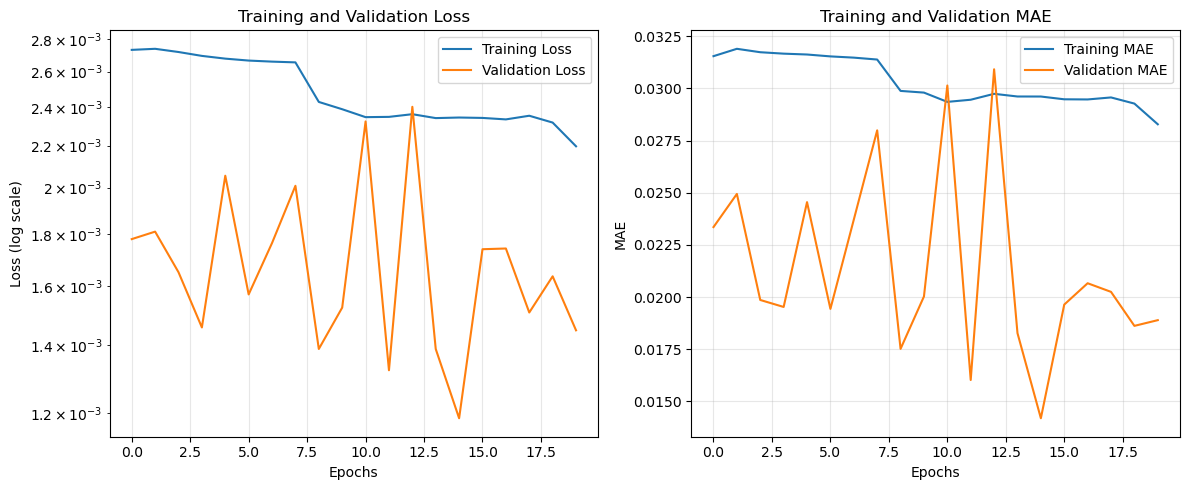

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('Training and Validation MAE')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Predicciones vs valores reales**

>> Corrección de ToF aplicada
   * y_test_inverse (sin ToF) range: [348.22, 1898.23] ns
   * y_test_inverse_tof (con ToF) range: [-2.91, 1518.76] ns
   * y_pred_inverse_tof (con ToF) range: [-62.58, 1482.50] ns


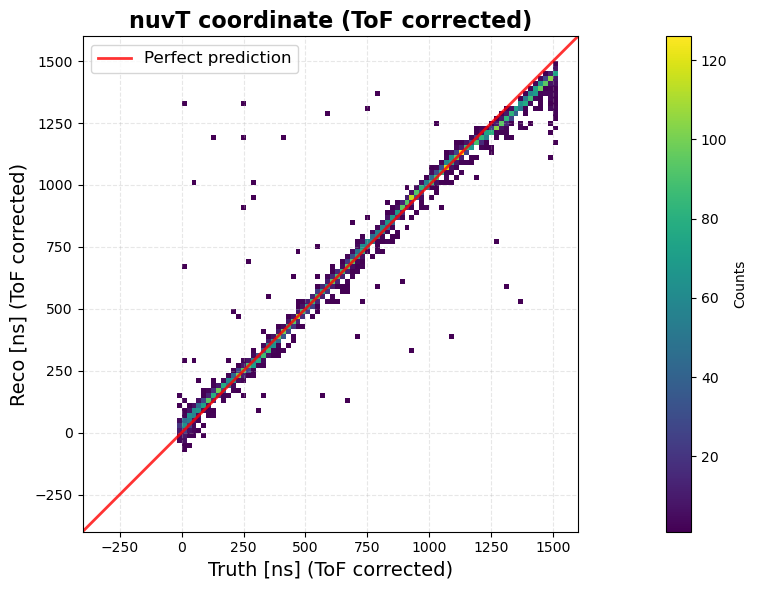


  MÉTRICAS DE PREDICCIÓN - nuvT (ToF corrected)
  MAE:  22.43 ns
  RMSE: 47.25 ns
  R²:   0.9887

Residuals statistics:
  Mean:   -5.42 ns
  Std:    46.94 ns
  Median: 0.22 ns


In [100]:
# Revertir la normalización para obtener los valores originales
y_pred_inverse = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Obtener los índices del test set para aplicar ToF corrections correspondientes
# Necesitamos recuperar ToF_inside para los eventos del test set
ToF_inside_np = np.array(ToF_inside)  # Convertir a numpy si no lo está

# Crear índices para el split
from sklearn.model_selection import train_test_split
_, test_indices = train_test_split(
    np.arange(len(input_data)), 
    test_size=0.05, 
    random_state=42
)

# Obtener ToF_inside y ToF_outside para los eventos de test
ToF_inside_test = ToF_inside_np[test_indices].reshape(-1, 1)
ToF_outside_value = 110 / 3E8 * 1E9  # 366.67 ns

# Aplicar corrección de ToF a y_test_inverse y y_pred_inverse
y_test_inverse_tof = y_test_inverse - ToF_inside_test - ToF_outside_value
y_pred_inverse_tof = y_pred_inverse - ToF_inside_test - ToF_outside_value

print(f">> Corrección de ToF aplicada")
print(f"   * y_test_inverse (sin ToF) range: [{y_test_inverse.min():.2f}, {y_test_inverse.max():.2f}] ns")
print(f"   * y_test_inverse_tof (con ToF) range: [{y_test_inverse_tof.min():.2f}, {y_test_inverse_tof.max():.2f}] ns")
print(f"   * y_pred_inverse_tof (con ToF) range: [{y_pred_inverse_tof.min():.2f}, {y_pred_inverse_tof.max():.2f}] ns")

import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

# Crear figura panorámica (más ancha, menos alta)
fig, ax = plt.subplots(figsize=(18, 6))

# 2D histogram con el mismo estilo que la imagen de referencia
hist = ax.hist2d(
    y_test_inverse_tof.flatten(), 
    y_pred_inverse_tof.flatten(), 
    bins=100,
    cmap='viridis',
    cmin=1,  # Mostrar bins con al menos 1 evento
    range=[[-400, 1600], [-400, 1600]]
)

# Colorbar
cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

# Línea de predicción perfecta
ax.plot([-400, 1600], [-400, 1600], 'r-', linewidth=2, label='Perfect prediction', alpha=0.8)

# Configuración de ejes y grid
ax.set_xlabel('Truth [ns] (ToF corrected)', fontsize=14)
ax.set_ylabel('Reco [ns] (ToF corrected)', fontsize=14)
ax.set_title('nuvT coordinate (ToF corrected)', fontsize=16, fontweight='bold')
ax.set_xlim([-400, 1600])
ax.set_ylim([-400, 1600])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12)

# Aspecto cuadrado para mejor visualización
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Calcular métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test_inverse_tof, y_pred_inverse_tof)
rmse = np.sqrt(mean_squared_error(y_test_inverse_tof, y_pred_inverse_tof))
r2 = r2_score(y_test_inverse_tof, y_pred_inverse_tof)

print(f"\n{'='*50}")
print(f"  MÉTRICAS DE PREDICCIÓN - nuvT (ToF corrected)")
print(f"{'='*50}")
print(f"  MAE:  {mae:.2f} ns")
print(f"  RMSE: {rmse:.2f} ns")
print(f"  R²:   {r2:.4f}")
print(f"{'='*50}")

# Estadísticas de residuos
residuals = y_pred_inverse_tof.flatten() - y_test_inverse_tof.flatten()
print(f"\nResiduals statistics:")
print(f"  Mean:   {np.mean(residuals):.2f} ns")
print(f"  Std:    {np.std(residuals):.2f} ns")
print(f"  Median: {np.median(residuals):.2f} ns")
print(f"{'='*50}")

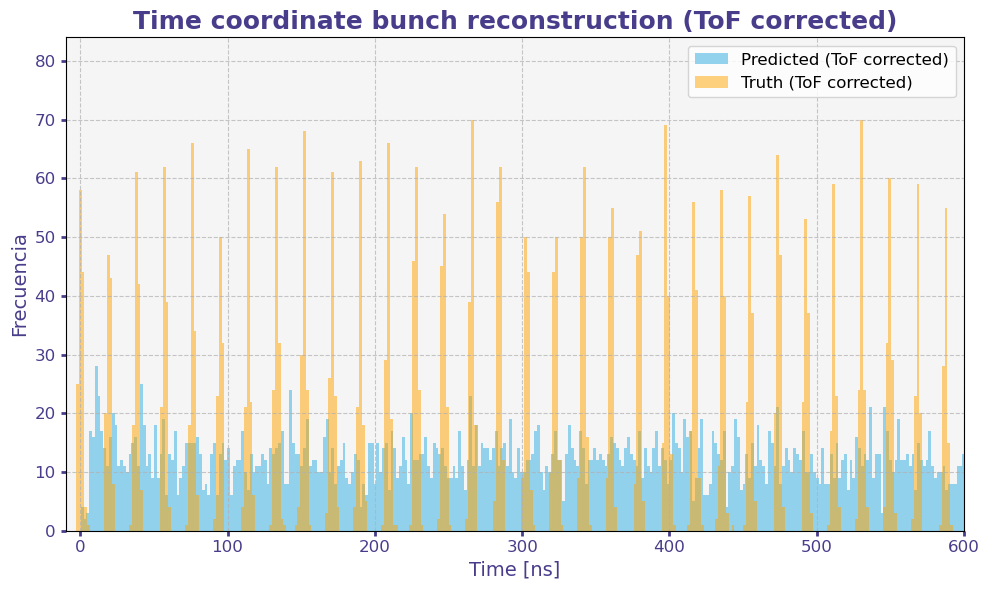

In [56]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Estilo del histograma - usando variables con ToF corregido
plt.hist(y_pred_inverse_tof, bins=800, color='skyblue', alpha=0.9, label='Predicted (ToF corrected)')
plt.hist(y_test_inverse_tof, bins=800, color='orange', alpha=0.5, label='Truth (ToF corrected)')

# Títulos y etiquetas con un toque de estilo
plt.title('Time coordinate bunch reconstruction (ToF corrected)', fontsize=18, fontweight='bold', color='darkslateblue')
plt.xlabel('Time [ns]', fontsize=14, color='darkslateblue')
plt.ylabel('Frecuencia', fontsize=14, color='darkslateblue')

# Mejorar la estética del gráfico
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12, width=2, colors='darkslateblue')
plt.xlim(-10, 600)
plt.legend(fontsize=12)

# Añadir un fondo suave al gráfico
plt.gca().set_facecolor('whitesmoke')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### lstm model

In [57]:
# Ruta donde guardar el modelo
model_save_path = "/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training/model_lstm_nuvT_temporal.keras"

# Guardar el modelo completo
model_lstm_attention.save(model_save_path)
print(f">> Modelo guardado en: {model_save_path}")

# También guardar el scaler para poder usarlo después
import pickle
scaler_save_path = "/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training/scaler_nuvT_temporal.pkl"
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f">> Scaler guardado en: {scaler_save_path}")

>> Modelo guardado en: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training/model_lstm_nuvT_temporal.keras
>> Scaler guardado en: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training/scaler_nuvT_temporal.pkl
